In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [23]:
import neuroboros as nb
import numpy as np
from scipy.stats import ttest_rel
import pandas as pd

In [3]:
results = nb.load('summary/pred_camcan/results.pkl')

In [4]:
list(results)

[('young', 'young'),
 ('mid', 'young'),
 ('old', 'young'),
 ('young', 'mid'),
 ('mid', 'mid'),
 ('old', 'mid'),
 ('young', 'old'),
 ('mid', 'old'),
 ('old', 'old')]

In [9]:
sids = set()
for test_grp in ['old', 'mid', 'young']:
    grp = set()
    grp = set([str(_) for _ in results[test_grp, 'young']]) & set([str(_) for _ in results[test_grp, 'old']])
    sids |= grp
sids = sorted(sids)

In [10]:
len(sids)

638

In [11]:
zz = {}
for tpl_grp in ['old', 'young']:
    zz[tpl_grp] = {}
    for test_grp in ['old', 'mid', 'young']:
        key = (test_grp, tpl_grp)
        res = results[key]
        for sid in res:
            if sid in sids:
                zz[tpl_grp][sid] = np.arctanh(res[sid]).mean(axis=0)

In [14]:
df = nb.load('camcan.pkl')

In [17]:
age = np.array(df.loc[sids]['Age'])

In [18]:
old = np.tanh([zz['old'][_].mean() for _ in sids])
young = np.tanh([zz['young'][_].mean() for _ in sids])

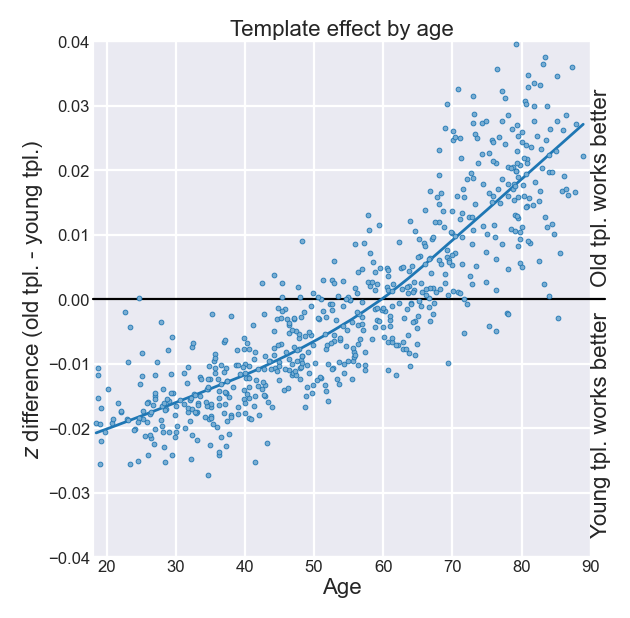

In [112]:
c = np.array(sns.color_palette('tab10')[0])
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
    # ax.axhline(0, color=[0.5]*3, zorder=1, lw=0.8)
    ax.plot([18, 92], [0, 0], 'k-', lw=0.8, clip_on=False, zorder=10)
    sns.regplot(x=age, y=diff, lowess=True, ax=ax, scatter=False, line_kws={'lw': 1, 'color': c, 'zorder': 10})
    ax.scatter(age, diff, s=3, lw=0.3, color=c*0.6+0.4, edgecolor=c, clip_on=False, zorder=10)
    diff = np.arctanh(old) - np.arctanh(young)
    ax.annotate('Young tpl. works better', (1, -0.002), xycoords=('axes fraction', 'data'), rotation=90, size=8, va='top')
    ax.annotate('Old tpl. works better', (1, 0.002), xycoords=('axes fraction', 'data'), rotation=90, size=8, va='bottom')
    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xlabel('Age', size=8, labelpad=1)
    ax.set_ylabel('$z$ difference (old tpl. - young tpl.)', size=8, labelpad=1)
    ax.set_title('Template effect by age', size=8, pad=2)
    ax.set_xlim([18, 90])
    ax.set_ylim([-0.04, 0.04])
    fig.subplots_adjust(left=0.13, right=0.96, top=0.94, bottom=0.08)
    plt.savefig('figures/pred_scatterdiff_camcan.png', dpi=300)
    plt.show()

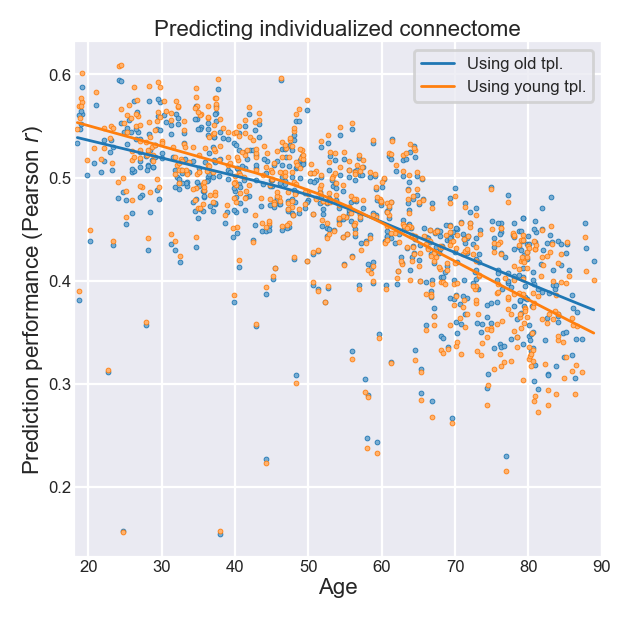

In [130]:
df = pd.DataFrame.from_dict(dict(age=age, old=old, young=young))
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
colors = np.array(sns.color_palette('tab10'))
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
    kwargs = dict(data=df, lowess=True, ax=ax,
                  line_kws={'lw': 1},
                  scatter_kws={'s': 3, 'alpha': 0.7})
    ax.scatter(df['age'], df['old'], s=3, lw=0.3, color=colors[0]*0.6+0.4, ec=colors[0])
    sns.regplot(x='age', y='old', **kwargs, label='Using old tpl.', scatter=False)
    ax.scatter(df['age'], df['young'], s=3, lw=0.3, color=colors[1]*0.6+0.4, ec=colors[1])
    sns.regplot(x='age', y='young', **kwargs, label='Using young tpl.', scatter=False)
    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xlabel('Age', size=8, labelpad=1)
    ax.set_ylabel('Prediction performance (Pearson $r$)', size=8, labelpad=1)
    ax.set_title('Predicting individualized connectome', size=8, pad=2)
    ax.set_xlim([18, 90])
    ax.legend(fontsize=6)
    fig.subplots_adjust(left=0.1, right=0.98, top=0.94, bottom=0.08)
    plt.savefig('figures/pred_scatter_camcan.png', dpi=300)
    plt.show()

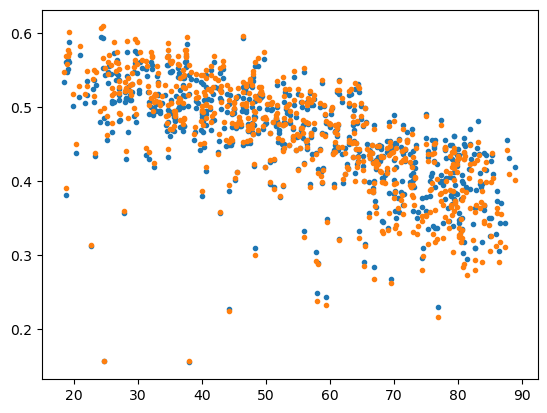

In [20]:
plt.plot(age, old, '.')
plt.plot(age, young, '.')
plt.show()

In [34]:
zz['old', 'old'].shape

(213, 19341)

In [36]:
colors = [mpl.colors.to_rgb(mpl.colors.cnames[_])
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]

config = [
    [0, zz['old', 'old']],
    [1, zz['old', 'young']],
    [2.5, zz['young', 'young']],
    [3.5, zz['young', 'old']],
]

In [57]:
d1 = (zz['old', 'old'] - zz['old', 'young']).mean(axis=1)
d2 = (zz['young', 'young'] - zz['young', 'old']).mean(axis=1)

m1 = d1.mean()
se1 = d1.std(ddof=1) / np.sqrt(len(d1))
m2 = d2.mean()
se2 = d2.std(ddof=1) / np.sqrt(len(d2))

In [58]:
colors = [np.array(mpl.colors.to_rgb(mpl.colors.cnames[_]))
          for _ in ['darkgreen', 'lightgreen', 'red', 'pink']]
c1 = (colors[0] + colors[1]) * 0.5
c2 = (colors[2] + colors[3]) * 0.5

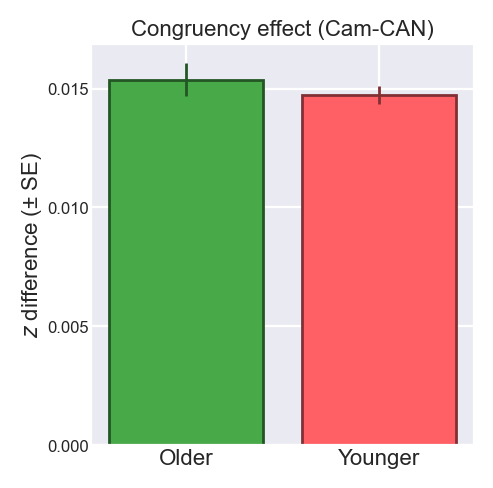

In [64]:
with sns.axes_style('darkgrid'):
    fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
    
    kwargs = dict(fmt='', lw=1)
    ax.bar(0, m1, color=c1, ec=c1*0.5)
    ax.bar(1, m2, color=c2, ec=c2*0.5)
    ax.errorbar(0, m1, yerr=se1, c=c1*0.5, **kwargs)
    ax.errorbar(1, m2, yerr=se2, c=c2*0.5, **kwargs)
    ax.tick_params(size=0, pad=1, labelsize=6)
    ax.set_xticks([0, 1], labels=['Older', 'Younger'], size=8)
    ax.set_ylabel('$z$ difference (± SE)', size=8, labelpad=1)
    ax.set_yticks(np.arange(4)*0.005)
    ax.set_title('Congruency effect (Cam-CAN)', size=8, pad=3)
    fig.subplots_adjust(left=0.16, top=0.92, bottom=0.06, right=0.98)
    plt.savefig('figures/pred_diff_camcan.png', dpi=300)
    plt.show()

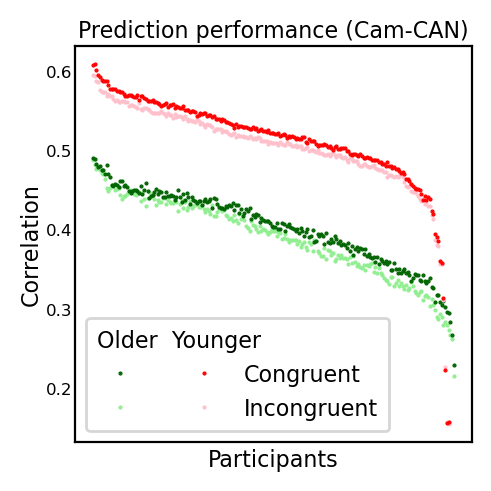

In [73]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)
handles = []
for ii, (a, b) in enumerate([[zz['old', 'old'], zz['old', 'young']], [zz['young', 'young'], zz['young', 'old']]]):
    a, b = a.mean(axis=1), b.mean(axis=1)
    idx = np.argsort((a + b))[::-1]
    a, b = np.tanh(a[idx]), np.tanh(b[idx])
    x = np.arange(len(a))
    kwargs = dict(markersize=1)
    handles += ax.plot(x, b, '.', color=colors[ii*2+1], **kwargs)
    handles += ax.plot(x, a, '.', color=colors[ii*2], **kwargs)
handles = [handles[_] for _ in [1, 0, 3, 2]]
ax.tick_params(size=0, pad=1, labelsize=6)
ax.set_ylabel('Correlation', size=8, labelpad=1)
ax.set_xticks([])
ax.set_xlabel('Participants', size=8, labelpad=2)
ax.set_title('Prediction performance (Cam-CAN)', size=8, pad=3)
ax.legend(handles=handles, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
fig.subplots_adjust(left=0.13, top=0.92, bottom=0.07, right=0.98)
plt.savefig('figures/pred_dist_camcan.png', dpi=300)
plt.show()

[-0.00677774  0.00040831  0.00190056  0.00312682  0.00426622  0.00538788
  0.00657919  0.00783413  0.00958063  0.01242262  0.03227335]


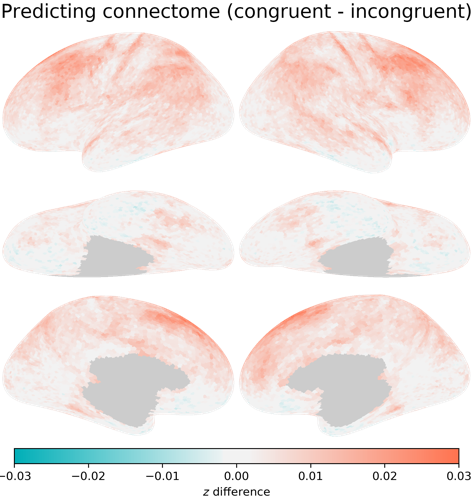

In [71]:
cmap = sns.diverging_palette(200, 20, s=100, l=65, sep=16, as_cmap=True)
c = ((zz['young', 'young'].mean(axis=0) - zz['young', 'old'].mean(axis=0)) + (zz['old', 'old'].mean(axis=0) - zz['old', 'young'].mean(axis=0))) * 0.2
nb.percentile(c)
vmax = 0.03
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap=cmap, title = "Predicting connectome (congruent - incongruent)", label='$z$ difference')
ic.save('figures/pred_map_camcan_average.png')
ic

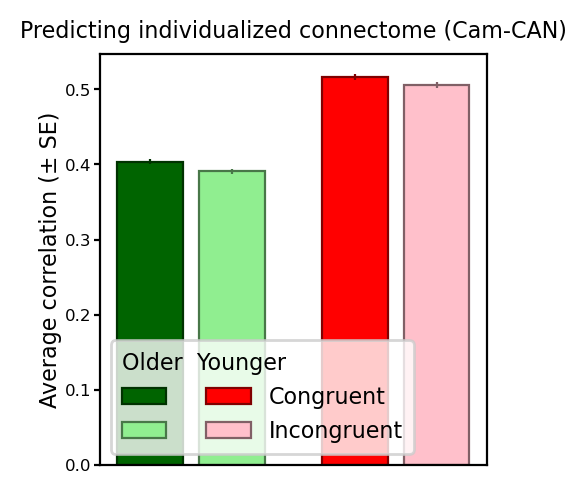

In [40]:
fig, ax = plt.subplots(1, 1, figsize=[_/3 for _ in [7, 7]], dpi=200)

bars = []
for ii, (x, z) in enumerate(config):
    c = colors[ii]
    ec = 0.5 * np.array(c)
    z = z.mean(axis=1)
    zm = z.mean()
    ze = z.std(ddof=1)/np.sqrt(len(z))
    m = np.tanh(zm)
    yerr = np.abs(np.tanh([zm-ze, zm+ze]) - m)
    b = ax.bar(x, m, color=c, ec=ec, lw=0.8)
    bars.append(b)
    ax.errorbar(x, m, yerr=yerr[:, None], color=ec, lw=0.8)
ax.set_xticks([])
ax.tick_params(size=2, pad=1, labelsize=6)
ax.set_ylabel('Average correlation (± SE)', size=8, labelpad=1)
ax.legend(handles=bars, labels=['', '', 'Congruent', 'Incongruent'], ncols=2, columnspacing=1, fontsize=8,
         title='Older  Younger', title_fontsize=8, alignment='left', borderpad=0.5, fancybox=True)
ax.set_title('Predicting individualized connectome (Cam-CAN)', size=8)
fig.subplots_adjust(left=0.15, right=0.98, top=0.9, bottom=0.02)
plt.savefig('figures/pred_errorbar_camcan.png', dpi=300)
plt.show()

In [52]:
a = np.tanh(zz['old', 'old'].mean(axis=0))
b = np.tanh(zz['old', 'young'].mean(axis=0))
c = (zz['old', 'old'] - zz['old', 'young']).mean(axis=0)
for d in [a, b, c]:
    nb.percentile(d)

[0.02932688 0.29088133 0.32939529 0.35647315 0.3777721  0.40060438
 0.42661955 0.45500334 0.47902119 0.50473571 0.60037697]
[0.03273629 0.28361793 0.31651001 0.34012005 0.36227126 0.38420403
 0.41152533 0.44046389 0.46512023 0.4939568  0.60668666]
[-0.03525016 -0.0030472   0.00199295  0.00580849  0.00958918  0.01356444
  0.01776703  0.02239316  0.0280021   0.03619495  0.09049157]


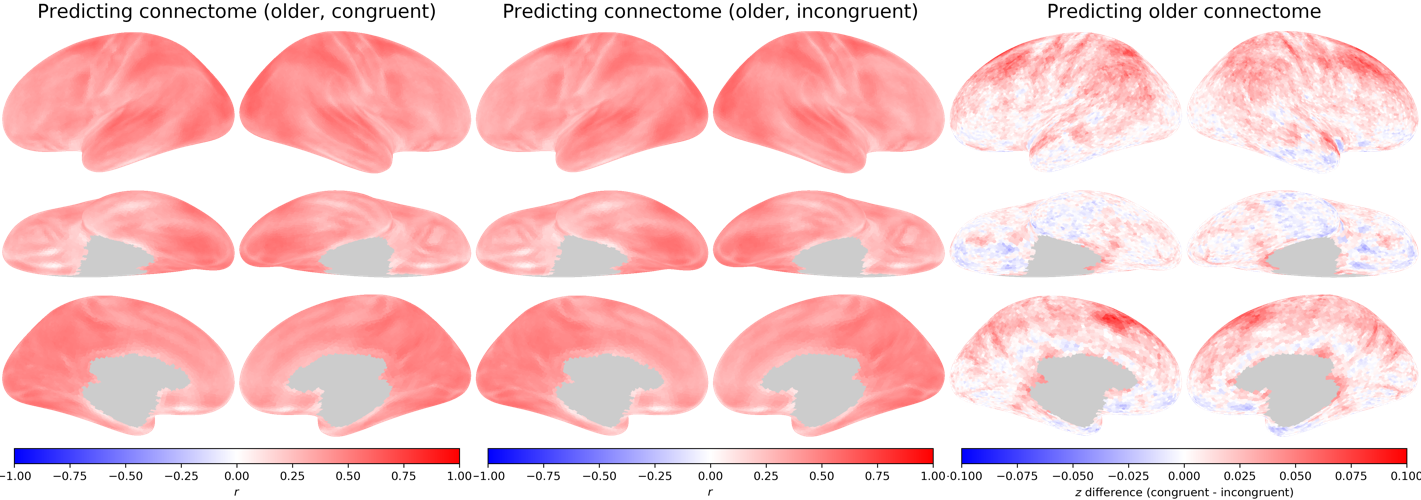

In [53]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (older, congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (older, incongruent)", label='$r$')
vmax = 0.1
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting older connectome", label='$z$ difference (congruent - incongruent)')
im = nb.Image.hstack([ia, ib, ic])
im.save('figures/pred_map_camcan_older.png')
ic.save('figures/pred_diffmap_camcan_older.png')
im

In [54]:
a = np.tanh(zz['young', 'young'].mean(axis=0))
b = np.tanh(zz['young', 'old'].mean(axis=0))
c = (zz['young', 'young'] - zz['young', 'old']).mean(axis=0)
for d in [a, b, c]:
    nb.percentile(d)

[0.0110615  0.34550976 0.42284933 0.45966578 0.49036589 0.51876539
 0.54750291 0.57649074 0.60810671 0.6504897  0.74531795]
[0.01422386 0.33539989 0.40792286 0.44430428 0.47533516 0.50515059
 0.53480411 0.56698673 0.60102564 0.64340344 0.74327973]
[-0.02959378 -0.00131811  0.00327497  0.00658494  0.00966904  0.01261643
  0.01589034  0.01984427  0.0250733   0.03376193  0.08616815]


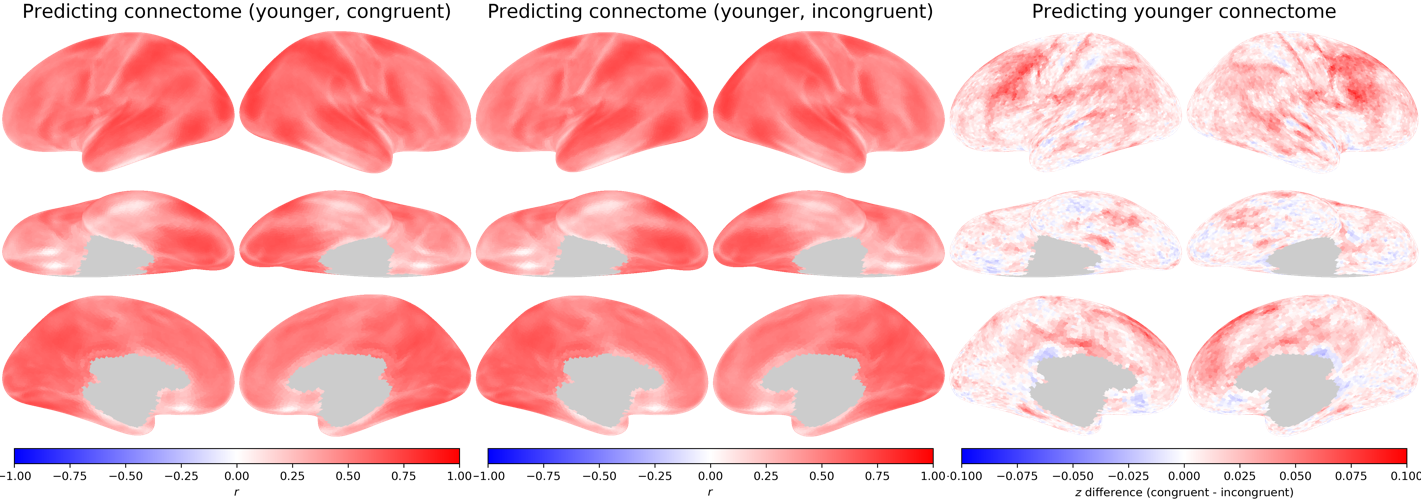

In [55]:
vmax = 1
ia = nb.plot(a, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (younger, congruent)", label='$r$')
ib = nb.plot(b, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting connectome (younger, incongruent)", label='$r$')
vmax = 0.1
ic = nb.plot(c, vmax=vmax, vmin=-vmax, cmap='bwr', title = "Predicting younger connectome", label='$z$ difference (congruent - incongruent)')
im = nb.Image.hstack([ia, ib, ic])
im.save('figures/pred_map_camcan_younger.png')
ic.save('figures/pred_diffmap_camcan_younger.png')
im